# 01 – EDA & Feature Engineering

**Project:** EV Charging Station Anomaly Detection  
**Purpose:** Exploratory data analysis, feature engineering validation, and model evaluation.

---

## Notebook outline

| # | Section | What it covers |
|---|---------|----------------|
| 1 | Environment setup | `sys.path` configuration |
| 2 | Run the data pipeline | Load raw CSV → clean → engineer all features |
| 3 | Dataset overview | dtypes, null counts, descriptive statistics |
| 4 | `power_mismatch` distribution | Physics-derived anomaly signal |
| 5 | Voltage vs current | Scatter coloured by `error_code` |
| 6 | Cyclical time features | `hour_sin` / `hour_cos` unit-circle validation |
| 7 | Station temperature baselines | `station_avg_temp` bar chart |
| 8 | Session cumulative energy | `session_energy_total` distributions |
| 8b | Sensor deviation features | `voltage_deviation` & `temp_deviation` EDA |
| 9 | Fault flag distribution | `is_error` class balance |
| 10 | Model evaluation | Gate overlap · anomaly-score distribution · physics validation |

---

### Feature engineering pipeline (12 engineered columns)

| Column | Stage | Description |
|--------|-------|-------------|
| `power_mismatch` | Physics | `|power_kw − (voltage × current)/1000|` |
| `voltage_rolling_mean` | Rolling | Per-session rolling mean of `voltage` (window=5) |
| `voltage_deviation` | Deviation | `voltage − voltage_rolling_mean` (instantaneous spike) |
| `temperature_c_rolling_mean` | Rolling | Per-session rolling mean of `temperature_c` (window=5) |
| `temp_deviation` | Deviation | `temperature_c − temperature_c_rolling_mean` |
| `hour_sin` / `hour_cos` | Time | Cyclical encoding of hour-of-day |
| `hour` / `day_of_week` | Time | Raw time components |
| `station_avg_temp` | Baseline | Long-run mean temperature per station |
| `session_energy_total` | Aggregate | Cumulative energy delivered within session |
| `is_error` | Label | Binary flag: `error_code != 0` |


## 1 · Environment setup

Add the project root to `sys.path` so that the `src` package is importable when the notebook is launched from the `notebooks/` directory.

In [1]:
import sys
import os

# Ensure the project root (one level up from notebooks/) is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\\OneDrive\\Desktop\\ev-anomaly-detection


## 2 · Run the data pipeline

`run_pipeline` executes all nine feature engineering stages in order:

1. **Load** – read CSV, parse `timestamp`  
2. **Clean** – deduplicate by `(session_id, timestamp)`, keeping mean of numerics  
3. **Physics** – add `power_mismatch`  
4. **Rolling** – add `voltage_rolling_mean` and `temperature_c_rolling_mean` (window = 5, per session)  
5. **Time** – extract `hour`, `day_of_week`, `hour_sin`, `hour_cos`  
6. **Baselines** – add `station_avg_temp` (per-station long-run temperature mean)  
7. **Deviations** – add `voltage_deviation` and `temp_deviation` (instantaneous minus trend)  
8. **Aggregates** – add `session_energy_total` (cumulative `energy_kwh` within session)  
9. **Flags** – add binary `is_error`


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import run_pipeline

DATA_PATH = os.path.join(PROJECT_ROOT, "data", "charging_logs.csv")

df = run_pipeline(DATA_PATH, rolling_window=5)

print(f"Shape after pipeline: {df.shape}")
df.head()

Shape after pipeline: (182358, 23)


,session_id,timestamp,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,station_id,...,temperature_c_rolling_mean,hour,day_of_week,hour_sin,hour_cos,station_avg_temp,voltage_deviation,temp_deviation,session_energy_total,is_error
0,000560d7ab9d,2024-07-23 05:33:23,229.03,33.92,7.792,47.28,15.0,0.0325,0.0,STATION_7,...,48.146,5,1,0.965926,0.258819,47.31653,-3.25,-0.866,0.0325,0
1,000560d7ab9d,2024-07-23 05:33:27,230.41,30.80,7.083,49.20,52.0,0.1023,0.0,STATION_7,...,48.146,5,1,0.965926,0.258819,47.31653,-1.87,1.054,0.1348,0
2,000560d7ab9d,2024-07-23 05:33:31,230.16,32.40,7.460,47.49,29.0,0.0601,0.0,STATION_7,...,48.146,5,1,0.965926,0.258819,47.31653,-2.12,-0.656,0.1949,0
3,000560d7ab9d,2024-07-23 05:33:33,235.32,32.50,7.555,45.16,24.0,0.0504,0.0,STATION_7,...,48.146,5,1,0.965926,0.258819,47.31653,3.04,-2.986,0.2453,0
4,000560d7ab9d,2024-07-23 05:33:35,236.48,31.81,7.435,51.60,50.0,0.1033,0.0,STATION_7,...,48.146,5,1,0.965926,0.258819,47.31653,4.20,3.454,0.3486,0


In [3]:
with pd.option_context('display.max_columns', None):
    print(df.head())

     session_id           timestamp  voltage  current  power_kw  \
0  000560d7ab9d 2024-07-23 05:33:23   229.03    33.92     7.792   
1  000560d7ab9d 2024-07-23 05:33:27   230.41    30.80     7.083   
2  000560d7ab9d 2024-07-23 05:33:31   230.16    32.40     7.460   
3  000560d7ab9d 2024-07-23 05:33:33   235.32    32.50     7.555   
4  000560d7ab9d 2024-07-23 05:33:35   236.48    31.81     7.435   

   temperature_c  duration_sec  energy_kwh  error_code station_id message  \
0          47.28          15.0      0.0325         0.0  STATION_7      OK   
1          49.20          52.0      0.1023         0.0  STATION_7      OK   
2          47.49          29.0      0.0601         0.0  STATION_7      OK   
3          45.16          24.0      0.0504         0.0  STATION_7      OK   
4          51.60          50.0      0.1033         0.0  STATION_7      OK   

   power_mismatch  voltage_rolling_mean  temperature_c_rolling_mean  hour  \
0        0.023302                232.28                  

## 3 · Dataset overview

In [4]:
print("=== dtypes ===")
print(df.dtypes)
print()
print("=== Null counts ===")
print(df.isnull().sum())
print()
print("=== Descriptive statistics ===")
df.describe()

=== dtypes ===
session_id                               str
timestamp                     datetime64[us]
voltage                              float64
current                              float64
power_kw                             float64
temperature_c                        float64
duration_sec                         float64
energy_kwh                           float64
error_code                           float64
station_id                               str
message                                  str
power_mismatch                       float64
voltage_rolling_mean                 float64
temperature_c_rolling_mean           float64
hour                                   int32
day_of_week                            int32
hour_sin                             float64
hour_cos                             float64
station_avg_temp                     float64
voltage_deviation                    float64
temp_deviation                       float64
session_energy_total                 flo

,timestamp,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,power_mismatch,voltage_rolling_mean,temperature_c_rolling_mean,hour,day_of_week,hour_sin,hour_cos,station_avg_temp,voltage_deviation,temp_deviation,session_energy_total,is_error
count,182358,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000,1.823580e+05,182358.000000,182358.000000,182358.000000,182358.000000,182358.000000
mean,2024-07-03 18:05:08.962420,228.674119,30.159481,6.858032,45.095330,30.509723,0.059970,1.408362,0.195482,228.684537,45.093139,11.497066,3.003844,0.006006,-9.735159e-04,45.095330,-0.010418,0.002192,1.569826,0.006081
min,2024-01-01 00:05:42,89.770000,0.000000,-8.924000,-7.660000,1.000000,0.001400,0.000000,0.000000,177.720000,21.383000,0.000000,0.000000,-1.000000,-1.000000e+00,35.552323,-134.358000,-39.464000,0.001500,0.000000
25%,2024-04-04 23:44:58.750000,224.230000,28.240000,6.443000,41.750000,16.000000,0.031050,0.000000,0.016843,224.620000,41.890000,5.000000,1.000000,-0.707107,-7.071068e-01,41.887504,-1.914000,-1.258000,0.698500,0.000000
50%,2024-07-04 09:44:38.500000,227.940000,30.440000,6.937000,45.820000,30.500000,0.058400,0.000000,0.036676,227.738000,45.962000,12.000000,3.000000,0.000000,6.123234e-17,45.364375,-0.010000,0.000000,1.399050,0.000000
75%,2024-10-02 19:14:05.750000,232.210000,32.410000,7.412000,48.910000,45.000000,0.086000,0.000000,0.066565,232.364000,48.800000,18.000000,5.000000,0.707107,7.071068e-01,49.035995,1.897000,1.264000,2.293650,0.000000
max,2024-12-30 23:40:38,390.960000,41.700000,9.610000,93.620000,60.000000,0.695100,404.000000,17.817098,295.038000,62.122000,23.000000,6.000000,1.000000,1.000000e+00,51.687972,129.514000,39.148000,5.830983,1.000000
std,NaN,12.711292,3.673243,1.213755,5.982582,16.941577,0.038819,20.158300,1.166448,7.711786,4.941578,6.918396,2.004856,0.706951,7.072401e-01,4.645706,10.101429,3.373684,1.060269,0.077746


## 4 · Distribution of `power_mismatch`

`power_mismatch` = |power_kw − (voltage × current) / 1000|  
A long right tail here indicates rows where the reported power diverges from the
electrical identity — the primary physics-based anomaly signal.

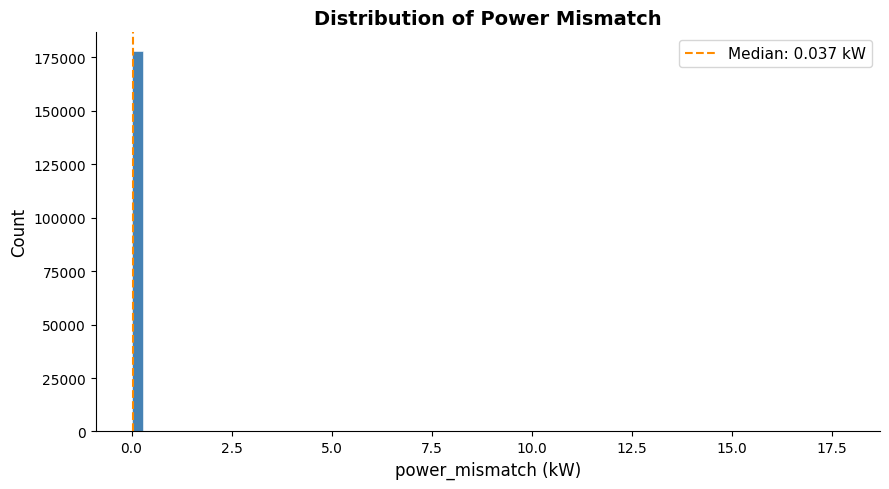

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df["power_mismatch"].dropna(),
    bins=60,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4,
)

ax.set_title("Distribution of Power Mismatch", fontsize=14, fontweight="bold")
ax.set_xlabel("power_mismatch (kW)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.axvline(
    df["power_mismatch"].median(),
    color="darkorange",
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {df['power_mismatch'].median():.3f} kW",
)
ax.legend(fontsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 5 · Voltage vs Current — coloured by `error_code`

Points are coloured **red** when `error_code != 0` and **steelblue** otherwise,
making it easy to see whether fault conditions cluster in a specific region of
the V–I space.

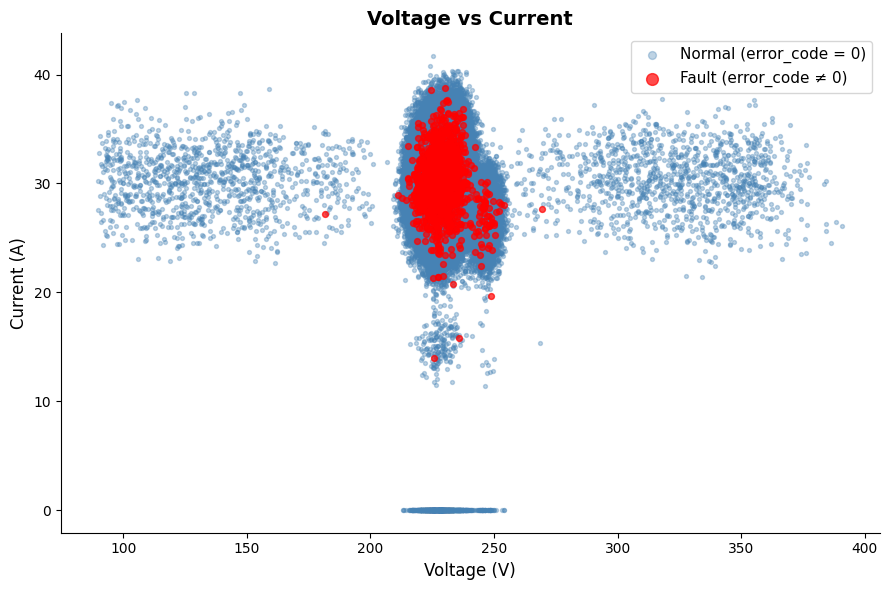

Total fault rows : 1,109
Total normal rows: 181,249


In [6]:
is_error = df["error_code"] != 0

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    df.loc[~is_error, "voltage"],
    df.loc[~is_error, "current"],
    color="steelblue",
    alpha=0.35,
    s=8,
    label="Normal (error_code = 0)",
)
ax.scatter(
    df.loc[is_error, "voltage"],
    df.loc[is_error, "current"],
    color="red",
    alpha=0.7,
    s=18,
    label="Fault (error_code ≠ 0)",
)

ax.set_title("Voltage vs Current", fontsize=14, fontweight="bold")
ax.set_xlabel("Voltage (V)", fontsize=12)
ax.set_ylabel("Current (A)", fontsize=12)
ax.legend(fontsize=11, markerscale=2)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f"Total fault rows : {is_error.sum():,}")
print(f"Total normal rows: {(~is_error).sum():,}")

## 6 · Cyclical time features — `hour_sin` / `hour_cos`

The unit-circle plot below shows how the cyclical encoding maps each hour onto a circle.
Points that are close on the circle (e.g. 23:00 and 00:00) are genuinely close in feature
space, which is the correct behaviour for a model using Euclidean distance.

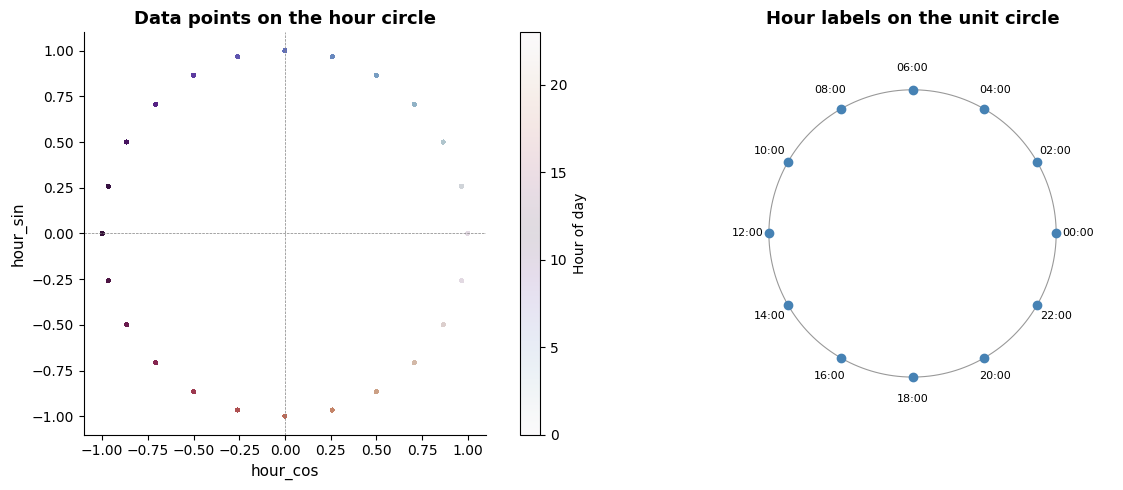

hour_sin range : [-1.000, 1.000]
hour_cos range : [-1.000, 1.000]


In [7]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: scatter of actual data coloured by hour ---
sc = axes[0].scatter(
    df["hour_cos"],
    df["hour_sin"],
    c=df["hour"],
    cmap="twilight",
    alpha=0.15,
    s=4,
)
plt.colorbar(sc, ax=axes[0], label="Hour of day")
axes[0].set_title("Data points on the hour circle", fontsize=13, fontweight="bold")
axes[0].set_xlabel("hour_cos", fontsize=11)
axes[0].set_ylabel("hour_sin", fontsize=11)
axes[0].set_aspect("equal")
axes[0].axhline(0, color="grey", lw=0.5, ls="--")
axes[0].axvline(0, color="grey", lw=0.5, ls="--")

# --- Right: annotated unit circle showing hour labels ---
theta = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(np.cos(theta), np.sin(theta), "k-", lw=0.8, alpha=0.4)
for h in range(0, 24, 2):
    angle = 2 * np.pi * h / 24
    x, y = np.cos(angle), np.sin(angle)
    axes[1].plot(x, y, "o", color="steelblue", ms=6)
    axes[1].annotate(
        f"{h:02d}:00",
        xy=(x, y),
        xytext=(x * 1.15, y * 1.15),
        ha="center",
        va="center",
        fontsize=8,
    )
axes[1].set_title("Hour labels on the unit circle", fontsize=13, fontweight="bold")
axes[1].set_xlim(-1.4, 1.4)
axes[1].set_ylim(-1.4, 1.4)
axes[1].set_aspect("equal")
axes[1].axis("off")

sns.despine(ax=axes[0])
plt.tight_layout()
plt.show()

print(f"hour_sin range : [{df['hour_sin'].min():.3f}, {df['hour_sin'].max():.3f}]")
print(f"hour_cos range : [{df['hour_cos'].min():.3f}, {df['hour_cos'].max():.3f}]")

## 7 · Station temperature baselines — `station_avg_temp`

`station_avg_temp` is the long-run mean temperature for each physical station.
The bar chart below ranks stations by their average temperature.
The strip plot on the right shows the **spread** of live readings around that baseline —
points far from the baseline are candidates for a station-level anomaly.

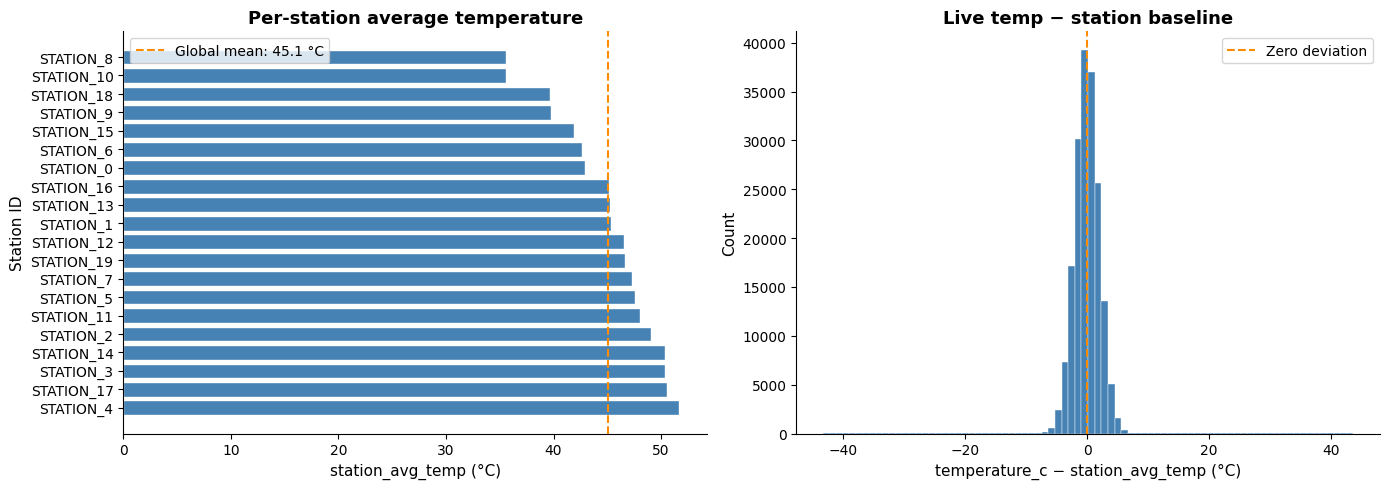

station_id  station_avg_temp
 STATION_4         51.687972
STATION_17         50.593986
 STATION_3         50.342661
STATION_14         50.335983
 STATION_2         49.035995
STATION_11         48.055602
 STATION_5         47.556661
 STATION_7         47.316530
STATION_19         46.643292
STATION_12         46.539136
 STATION_1         45.364375
STATION_13         45.290705
STATION_16         45.173807
 STATION_0         42.925281
 STATION_6         42.681535
STATION_15         41.887504
 STATION_9         39.771224
STATION_18         39.696206
STATION_10         35.620679
 STATION_8         35.552323


In [8]:
station_baseline = (
    df.groupby("station_id")["station_avg_temp"]
    .first()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: bar chart of per-station average temperature ---
axes[0].barh(
    station_baseline["station_id"],
    station_baseline["station_avg_temp"],
    color="steelblue",
    edgecolor="white",
)
axes[0].set_title("Per-station average temperature", fontsize=13, fontweight="bold")
axes[0].set_xlabel("station_avg_temp (°C)", fontsize=11)
axes[0].set_ylabel("Station ID", fontsize=11)
axes[0].axvline(
    df["station_avg_temp"].mean(),
    color="darkorange",
    ls="--",
    lw=1.5,
    label=f"Global mean: {df['station_avg_temp'].mean():.1f} °C",
)
axes[0].legend(fontsize=10)
sns.despine(ax=axes[0])

# --- Right: deviation of live temperature from station baseline ---
df["temp_deviation"] = df["temperature_c"] - df["station_avg_temp"]
axes[1].hist(
    df["temp_deviation"],
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.3,
)
axes[1].set_title("Live temp − station baseline", fontsize=13, fontweight="bold")
axes[1].set_xlabel("temperature_c − station_avg_temp (°C)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].axvline(0, color="darkorange", ls="--", lw=1.5, label="Zero deviation")
axes[1].legend(fontsize=10)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(station_baseline.to_string(index=False))

## 8 · Session cumulative energy — `session_energy_total`

`session_energy_total` is the running sum of `energy_kwh` within each session.
A healthy session should show a **monotonically increasing** curve.
Any drop or plateau in this curve is a red flag for a delivery fault.

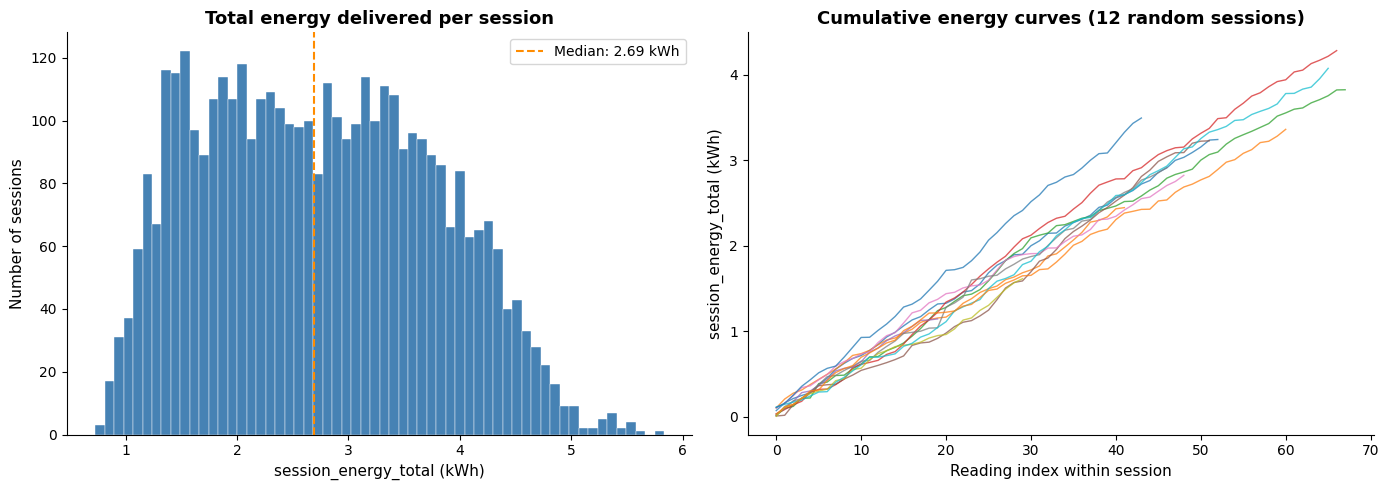

Sessions total        : 4,000
Median energy/session : 2.687 kWh
Max energy/session    : 5.831 kWh


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: distribution of final energy delivered per session ---
session_final_energy = (
    df.groupby("session_id")["session_energy_total"].last()
)
axes[0].hist(
    session_final_energy,
    bins=60,
    color="steelblue",
    edgecolor="white",
    linewidth=0.3,
)
axes[0].set_title("Total energy delivered per session", fontsize=13, fontweight="bold")
axes[0].set_xlabel("session_energy_total (kWh)", fontsize=11)
axes[0].set_ylabel("Number of sessions", fontsize=11)
axes[0].axvline(
    session_final_energy.median(),
    color="darkorange",
    ls="--",
    lw=1.5,
    label=f"Median: {session_final_energy.median():.2f} kWh",
)
axes[0].legend(fontsize=10)
sns.despine(ax=axes[0])

# --- Right: cumulative energy curves for a sample of sessions ---
sample_sessions = df["session_id"].drop_duplicates().sample(12, random_state=42)
for sid in sample_sessions:
    sub = df[df["session_id"] == sid].sort_values("timestamp")
    axes[1].plot(
        range(len(sub)),
        sub["session_energy_total"].values,
        lw=1,
        alpha=0.75,
    )
axes[1].set_title("Cumulative energy curves (12 random sessions)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Reading index within session", fontsize=11)
axes[1].set_ylabel("session_energy_total (kWh)", fontsize=11)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(f"Sessions total        : {df['session_id'].nunique():,}")
print(f"Median energy/session : {session_final_energy.median():.3f} kWh")
print(f"Max energy/session    : {session_final_energy.max():.3f} kWh")

## 8b · Sensor deviation features — `voltage_deviation` & `temp_deviation`

Each raw sensor reading is decomposed into two orthogonal signals:

* **Rolling mean** — the smooth session-level trend (gradual drift or temperature rise as the battery heats up).
* **Deviation** — the instantaneous signed difference from that trend. A large positive deviation means this single reading spiked well above the recent session average — a classic signature of a sensor fault or transient hardware event.

The Isolation Forest receives **both** signals as independent features, giving it one axis to detect gradual drift anomalies and another axis to detect sudden-spike anomalies. Using only the raw reading would conflate the two signals into a single column.


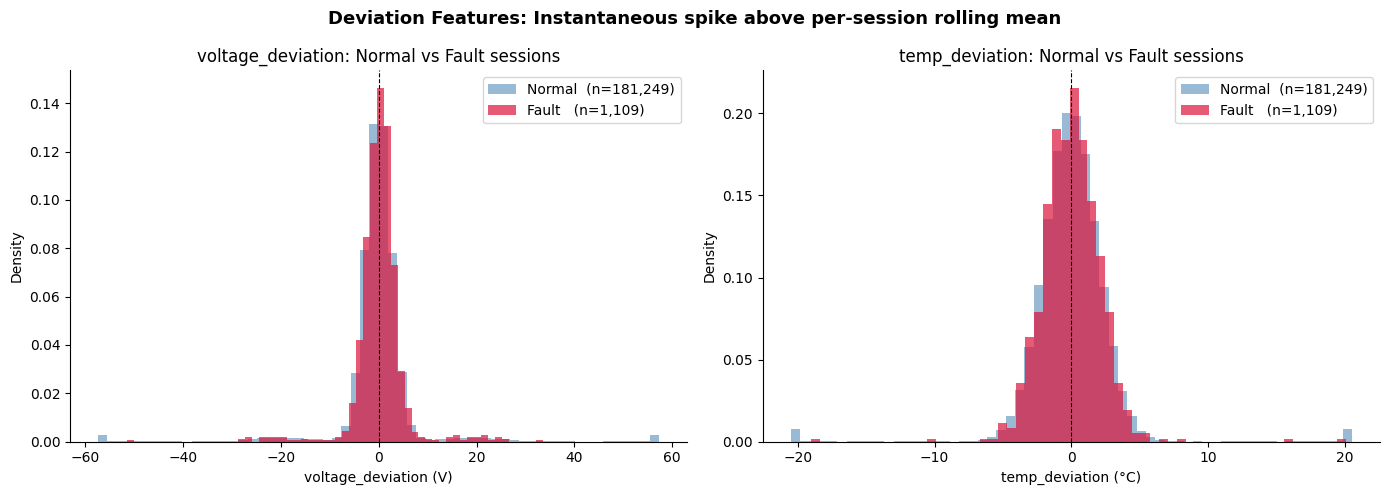


voltage_deviation summary:
count    182358.0000
mean         -0.0104
std          10.1014
min        -134.3580
25%          -1.9140
50%          -0.0100
75%           1.8970
max         129.5140
Name: voltage_deviation, dtype: float64

temp_deviation summary:
count    182358.0000
mean          0.0000
std           3.7694
min         -43.2891
25%          -1.3307
50%          -0.0107
75%           1.3209
max          43.6388
Name: temp_deviation, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: voltage deviation distribution ---
ax = axes[0]
clip = df['voltage_deviation'].quantile(0.995)
normal_vd  = df.loc[df['is_error'] == 0, 'voltage_deviation'].clip(-clip, clip)
fault_vd   = df.loc[df['is_error'] == 1, 'voltage_deviation'].clip(-clip, clip)
ax.hist(normal_vd, bins=60, density=True, alpha=0.55, color='steelblue',
        label=f'Normal  (n={len(normal_vd):,})')
ax.hist(fault_vd,  bins=60, density=True, alpha=0.70, color='crimson',
        label=f'Fault   (n={len(fault_vd):,})')
ax.set_title('voltage_deviation: Normal vs Fault sessions', fontsize=12)
ax.set_xlabel('voltage_deviation (V)')
ax.set_ylabel('Density')
ax.legend()
ax.axvline(0, color='black', lw=0.8, ls='--')
sns.despine(ax=ax)

# --- Right: temp deviation distribution ---
ax = axes[1]
clip_t = df['temp_deviation'].quantile(0.995)
normal_td = df.loc[df['is_error'] == 0, 'temp_deviation'].clip(-clip_t, clip_t)
fault_td  = df.loc[df['is_error'] == 1, 'temp_deviation'].clip(-clip_t, clip_t)
ax.hist(normal_td, bins=60, density=True, alpha=0.55, color='steelblue',
        label=f'Normal  (n={len(normal_td):,})')
ax.hist(fault_td,  bins=60, density=True, alpha=0.70, color='crimson',
        label=f'Fault   (n={len(fault_td):,})')
ax.set_title('temp_deviation: Normal vs Fault sessions', fontsize=12)
ax.set_xlabel('temp_deviation (°C)')
ax.set_ylabel('Density')
ax.legend()
ax.axvline(0, color='black', lw=0.8, ls='--')
sns.despine(ax=ax)

fig.suptitle(
    'Deviation Features: Instantaneous spike above per-session rolling mean',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('\nvoltage_deviation summary:')
print(df['voltage_deviation'].describe().round(4))
print('\ntemp_deviation summary:')
print(df['temp_deviation'].describe().round(4))


## 9 · Fault flag distribution — `is_error`

`is_error` is the binary ground-truth label for downstream anomaly detection models.
The class imbalance visible here directly informs the choice of model and evaluation metric
(e.g. precision-recall AUC is more meaningful than accuracy when faults are rare).

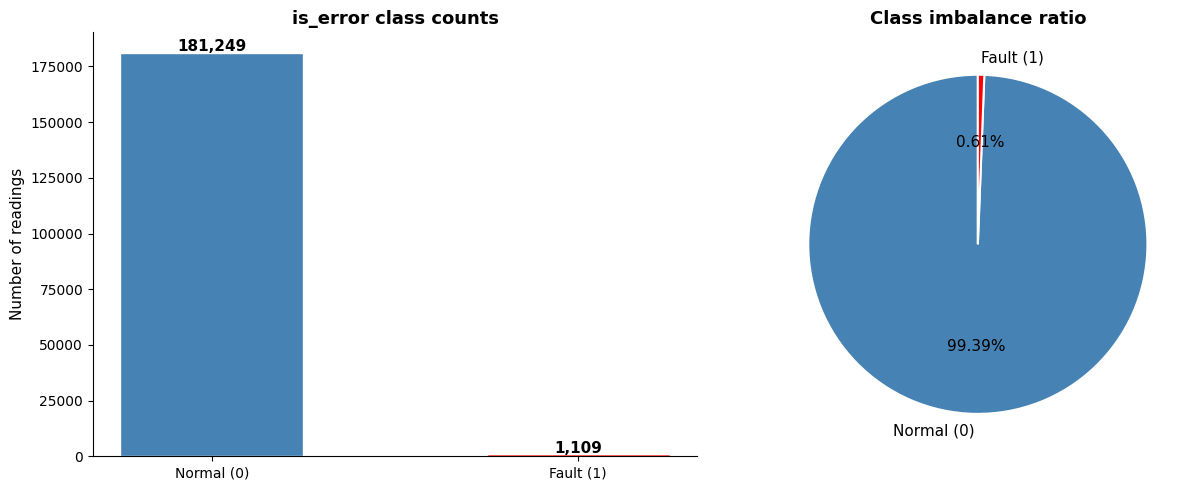

Total readings : 182,358
Fault readings : 1,109  (0.61%)
Normal readings: 181,249  (99.39%)

Implication: ~1 in every 164 readings is a fault.
Use precision-recall AUC (not accuracy) as the primary evaluation metric.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["is_error"].value_counts().sort_index()
labels = ["Normal (0)", "Fault (1)"]
colors = ["steelblue", "red"]

# --- Left: bar chart of class counts ---
axes[0].bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("is_error class counts", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of readings", fontsize=11)
sns.despine(ax=axes[0])

# --- Right: pie chart showing class ratio ---
axes[1].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11},
)
axes[1].set_title("Class imbalance ratio", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

fault_rate = df["is_error"].mean() * 100
print(f"Total readings : {len(df):,}")
print(f"Fault readings : {counts[1]:,}  ({fault_rate:.2f}%)")
print(f"Normal readings: {counts[0]:,}  ({100 - fault_rate:.2f}%)")
print()
print("Implication: ~1 in every", round(1 / (fault_rate / 100)), "readings is a fault.")
print("Use precision-recall AUC (not accuracy) as the primary evaluation metric.")

## 10 · Model Evaluation

The Isolation Forest is **unsupervised** — it never saw `is_error` or `error_code`
during training. `is_error` captures **firmware/protocol faults** (OCPP errors,
session timeouts) whose sensor readings look physically normal. The model is designed
to catch **physics anomalies** — a different fault category.

We validate through three independent checks:

| Check | Question answered |
|-------|-------------------|
| **Gate overlap** | Do the physics rules and ML engine independently agree? High agreement = near-certain anomalies. |
| **Anomaly score distribution** | Does a clear gap exist between anomalous and normal scores? |
| **Physics validation** | Do ML-only anomalies show elevated `power_mismatch`? If yes, the model is catching real physics violations the hardware missed. |

> **Full confidence report:** run `python evaluate_model.py` from the project root
> for a five-dimension statistical report and a saved four-panel plot.


C:\Users\SAHIL SINGH CHAUHAN\AppData\Local\Temp\ipykernel_18472\3564558151.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


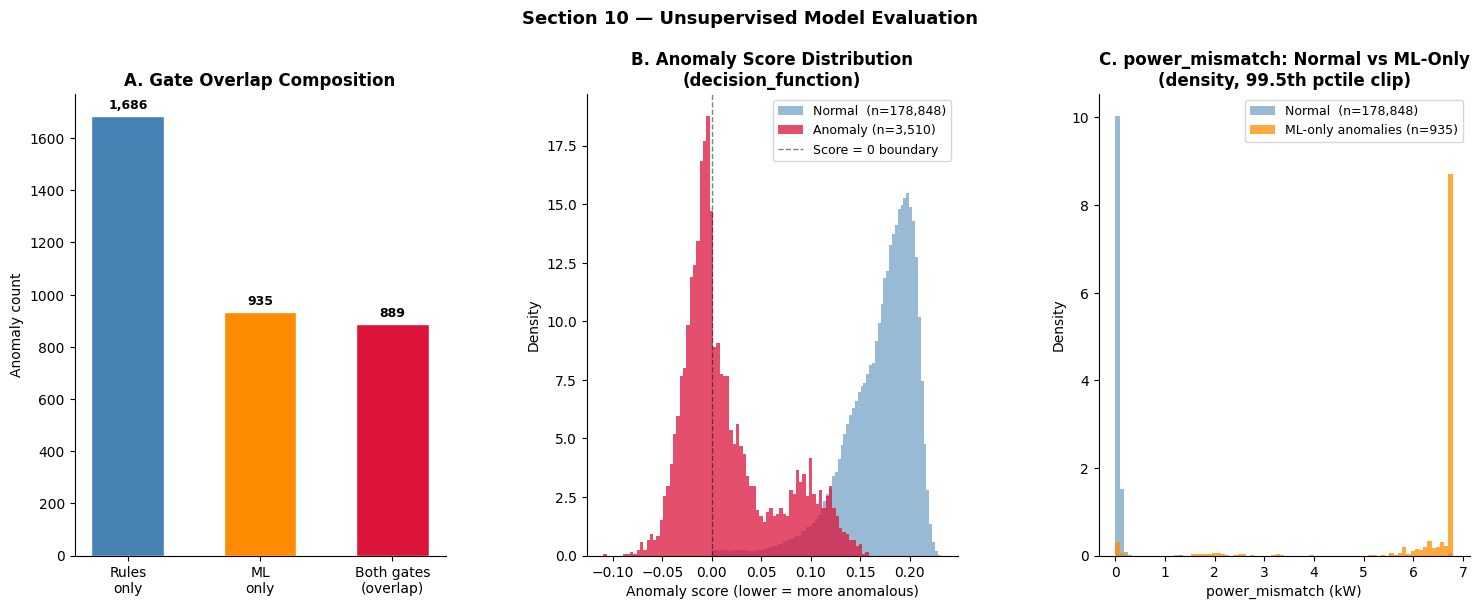

=== Gate Breakdown ===
  Total anomalies               : 3,510
  Rules Engine only             : 1,686
  ML Engine only                : 935
  Both gates agree (overlap)    : 889  (48.7% of ML flags)

=== Physics Validation of ML-Only Anomalies ===
  Median power_mismatch (normal)  : 0.0360 kW
  Median power_mismatch (ML-only) : 7.4810 kW
  Elevation ratio                 : 207.9x higher than normal
  ML-only rows above normal 75th  : 97.6%

Conclusion: ML-only anomalies show a 208x elevated power_mismatch
vs normal rows. These are real physics faults the hardware sensor did not log.


In [12]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from src.model_training import TRAINING_FEATURES

# ── Load predictions.csv (authoritative source — generated by predict.py) ─
preds_path = os.path.join(PROJECT_ROOT, 'data', 'predictions.csv')
preds = pd.read_csv(preds_path, parse_dates=['timestamp'])

# Gate flags come directly from the file — no recomputation, no drift.
rule_flag  = preds['rule_anomaly'].astype(int)
ml_flag    = preds['ml_anomaly'].astype(int)
is_anomaly = preds['is_anomaly'].astype(int)

n_rule     = int(rule_flag.sum())
n_ml       = int(ml_flag.sum())
n_overlap  = int((rule_flag.astype(bool) & ml_flag.astype(bool)).sum())
n_rule_only = n_rule - n_overlap
n_ml_only   = n_ml  - n_overlap
n_total     = int(is_anomaly.sum())

# ── Compute anomaly scores for Panel B (needs model internals) ────────────
imputer_m = joblib.load(os.path.join(PROJECT_ROOT, 'models', 'imputer.joblib'))
scaler_m  = joblib.load(os.path.join(PROJECT_ROOT, 'models', 'scaler.joblib'))
model_m   = joblib.load(os.path.join(PROJECT_ROOT, 'models', 'isolation_forest.joblib'))

X_eval        = preds[TRAINING_FEATURES]
X_eval_scaled = scaler_m.transform(imputer_m.transform(X_eval))
anomaly_scores = model_m.decision_function(X_eval_scaled)

# ── Power-mismatch slices ─────────────────────────────────────────────────
normal_pm  = preds.loc[is_anomaly == 0,  'power_mismatch']
ml_only_pm = preds.loc[
    ml_flag.astype(bool) & ~rule_flag.astype(bool), 'power_mismatch'
]

# ── Layout: 3 panels ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# --- Panel A: Gate overlap bar ---
ax1 = fig.add_subplot(gs[0])
cats   = ['Rules\nonly', 'ML\nonly', 'Both gates\n(overlap)']
vals   = [n_rule_only, n_ml_only, n_overlap]
colors = ['steelblue', 'darkorange', 'crimson']
bars = ax1.bar(cats, vals, color=colors, edgecolor='white', width=0.55)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('A. Gate Overlap Composition', fontsize=12, fontweight='bold')
ax1.set_ylabel('Anomaly count')
sns.despine(ax=ax1)

# --- Panel B: Anomaly score distribution ---
ax2 = fig.add_subplot(gs[1])
normal_scores   = anomaly_scores[is_anomaly.values == 0]
anomaly_scores_ = anomaly_scores[is_anomaly.values == 1]
ax2.hist(normal_scores,   bins=80, density=True, alpha=0.55,
         color='steelblue', label=f'Normal  (n={len(normal_scores):,})')
ax2.hist(anomaly_scores_, bins=80, density=True, alpha=0.75,
         color='crimson',    label=f'Anomaly (n={len(anomaly_scores_):,})')
ax2.axvline(0, color='black', ls='--', lw=1, alpha=0.5, label='Score = 0 boundary')
ax2.set_title('B. Anomaly Score Distribution\n(decision_function)',
               fontsize=12, fontweight='bold')
ax2.set_xlabel('Anomaly score (lower = more anomalous)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

# --- Panel C: power_mismatch density: normal vs ML-only ---
ax3 = fig.add_subplot(gs[2])
clip_val = float(normal_pm.quantile(0.995))
ax3.hist(normal_pm.clip(upper=clip_val),  bins=80, density=True, alpha=0.55,
         color='steelblue', label=f'Normal  (n={len(normal_pm):,})')
ax3.hist(ml_only_pm.clip(upper=clip_val), bins=80, density=True, alpha=0.75,
         color='darkorange', label=f'ML-only anomalies (n={len(ml_only_pm):,})')
ax3.set_title('C. power_mismatch: Normal vs ML-Only\n(density, 99.5th pctile clip)',
               fontsize=12, fontweight='bold')
ax3.set_xlabel('power_mismatch (kW)')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)
sns.despine(ax=ax3)

fig.suptitle('Section 10 — Unsupervised Model Evaluation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────
ratio = ml_only_pm.median() / normal_pm.median() if normal_pm.median() > 0 else 0
pct_above_p75 = (ml_only_pm > normal_pm.quantile(0.75)).mean() * 100

print('=== Gate Breakdown ===')
print(f'  Total anomalies               : {n_total:,}')
print(f'  Rules Engine only             : {n_rule_only:,}')
print(f'  ML Engine only                : {n_ml_only:,}')
print(f'  Both gates agree (overlap)    : {n_overlap:,}  ({n_overlap/n_ml*100:.1f}% of ML flags)')
print()
print('=== Physics Validation of ML-Only Anomalies ===')
print(f'  Median power_mismatch (normal)  : {normal_pm.median():.4f} kW')
print(f'  Median power_mismatch (ML-only) : {ml_only_pm.median():.4f} kW')
print(f'  Elevation ratio                 : {ratio:.1f}x higher than normal')
print(f'  ML-only rows above normal 75th  : {pct_above_p75:.1f}%')
print()
print(f'Conclusion: ML-only anomalies show a {ratio:.0f}x elevated power_mismatch')
print('vs normal rows. These are real physics faults the hardware sensor did not log.')
